In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the Excel file directly
# Note: 'Year 2010-2011' matches the standard structure of the Online Retail II file
print("Loading Excel file... (This may take a minute as Excel files are compressed)")
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# Preliminary inspection
print("--- Initial Inspection ---")
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values Breakdown:")
print(df.isnull().sum())

Loading Excel file... (This may take a minute as Excel files are compressed)
--- Initial Inspection ---
Dataset Shape: (541910, 8)

Missing Values Breakdown:
Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64


In [37]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Amount
count,401605.000000,401605,401605.000000,401605.000000,401605.000000
mean,12.183245,2011-07-10 12:08:56.555570944,3.474100,15281.154341,20.613631
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,-168469.600000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000,4.250000
50%,5.000000,2011-07-29 15:40:00,1.950000,15145.000000,11.700000
75%,12.000000,2011-10-20 12:00:00,3.750000,16784.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,250.282726,NaN,69.763952,1714.008869,430.351683


In [13]:
# overview
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [14]:
# 1. Handle missing values 
# Dropping rows with missing Customer ID for strict transaction tracking
df.dropna(subset=['Customer ID'], inplace=True)

# 2. Eliminate duplicate transactions
df.drop_duplicates(inplace=True)

print(f"Dataset Shape after Removing the duplicates: {df.shape}")

Dataset Shape after Removing the duplicates: (401605, 8)


In [15]:
# 3. Explicitly convert 'InvoiceDate' to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 4. Engineer 'Amount' (Revenue) feature using your exact column names
df['Amount'] = df['Quantity'] * df['Price']

print(f"Dataset Shape after adding the revenue (Amount) column: {df.shape}")

Dataset Shape after adding the revenue (Amount) column: (401605, 9)


In [16]:
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [20]:
# =====================================================================
# STEP 5: SEPARATE CANCELLATIONS FROM SUCCESSFUL SALES
# =====================================================================

# 1. Grab Cancelled Orders
# We check if the 'Invoice' column starts with the letter 'C'.
# If it does, we save those rows into a separate bucket called 'df_cancellations'.
is_canceled = df['Invoice'].astype(str).str.startswith('C', na=False)
df_cancellations = df[is_canceled].copy()

# 2. Grab Successful Sales Only
# The '~' symbol means 'NOT'. So we ask for rows that do NOT start with 'C'.
# We also add an '&' (AND) rule to make sure the 'Quantity' is greater than 0.
is_successful = ~df['Invoice'].astype(str).str.startswith('C', na=False)
has_positive_qty = df['Quantity'] > 0

df_cleaned = df[is_successful & has_positive_qty].copy()


# =====================================================================
# STEP 6: BREAK DOWN THE DATES FOR TREND ANALYSIS
# =====================================================================

# Extract 'Year-Month' format (e.g., '2011-05') to group sales data by month easily
df_cleaned['YearMonth'] = df_cleaned['InvoiceDate'].dt.to_period('M')

# Extract the full name of the month (e.g., 'January', 'February') for clean chart labels
df_cleaned['MonthName'] = df_cleaned['InvoiceDate'].dt.strftime('%B')

# Extract the weekday name (e.g., 'Monday', 'Tuesday') to see which days are busiest
df_cleaned['DayOfWeek'] = df_cleaned['InvoiceDate'].dt.strftime('%A')

# Extract just the hour number (from 0 to 23) to analyze peak shopping times during the day
df_cleaned['Hour'] = df_cleaned['InvoiceDate'].dt.hour


# =====================================================================
# STEP 7: PRINT INTEGRITY CHECK
# =====================================================================
print("--- Post-Cleaning Integrity Check ---")
print(f"Successful Sales Dataset Shape: {df_cleaned.shape}")
print(f"Isolated Cancellations Count: {df_cancellations.shape[0]}")
print(f"Remaining Missing Values:\n{df_cleaned.isnull().sum()}")

--- Post-Cleaning Integrity Check ---
Successful Sales Dataset Shape: (392733, 13)
Isolated Cancellations Count: 8872
Remaining Missing Values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Amount         0
YearMonth      0
MonthName      0
DayOfWeek      0
Hour           0
dtype: int64


In [21]:
# overview
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


--- Core Business Metrics ---
Total Revenue:  £ 8,887,226.89
Average Sale:    £ 22.63
Median Sale:     £ 12.39


C:\Users\muham\AppData\Local\Temp\ipykernel_25408\3301391645.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="Blues_r")


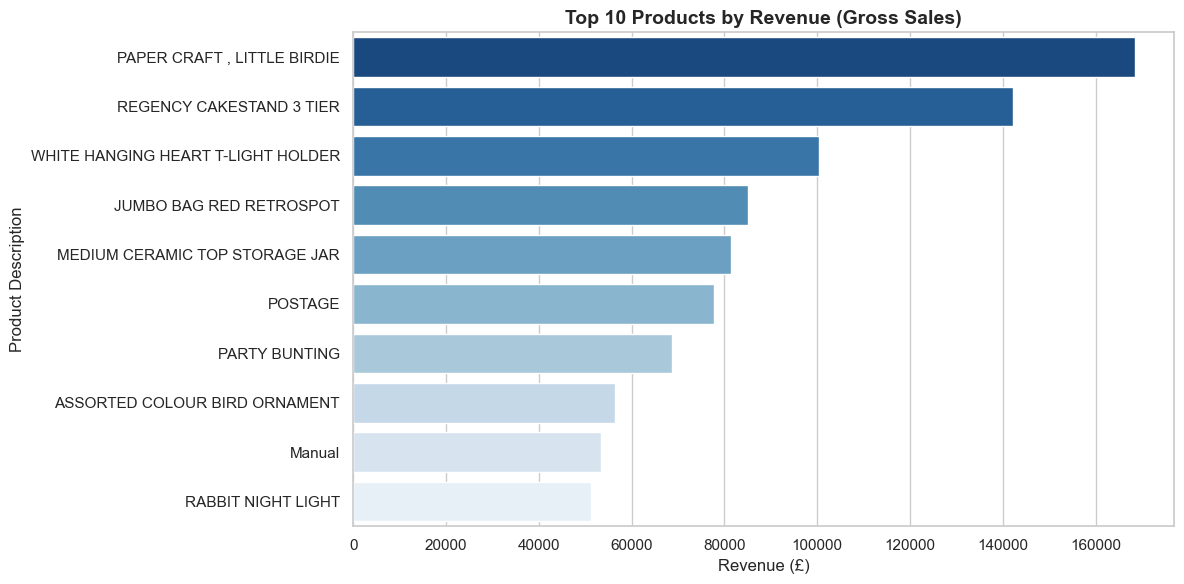

In [23]:
# =====================================================================
# STEP 1: CALCULATE BASIC STATISTICS (REPORT METRICS)
# =====================================================================
total_revenue = df_cleaned['Amount'].sum()
average_sale = df_cleaned['Amount'].mean()
median_sale = df_cleaned['Amount'].median()

print("--- Core Business Metrics ---")
print(f"Total Revenue:  £ {total_revenue:,.2f}")
print(f"Average Sale:    £ {average_sale:,.2f}")
print(f"Median Sale:     £ {median_sale:,.2f}")

# =====================================================================
# STEP 2: VISUALIZATION - TOP 10 PRODUCTS BY REVENUE
# =====================================================================
plt.figure(figsize=(12, 6))

# Group by Description, sum the Amount, and grab the top 10 largest
top_products = df_cleaned.groupby('Description')['Amount'].sum().nlargest(10)

# Plot a professional bar chart using Seaborn
sns.barplot(x=top_products.values, y=top_products.index, palette="Blues_r")

plt.title('Top 10 Products by Revenue (Gross Sales)', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (£)', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.tight_layout()
plt.show()


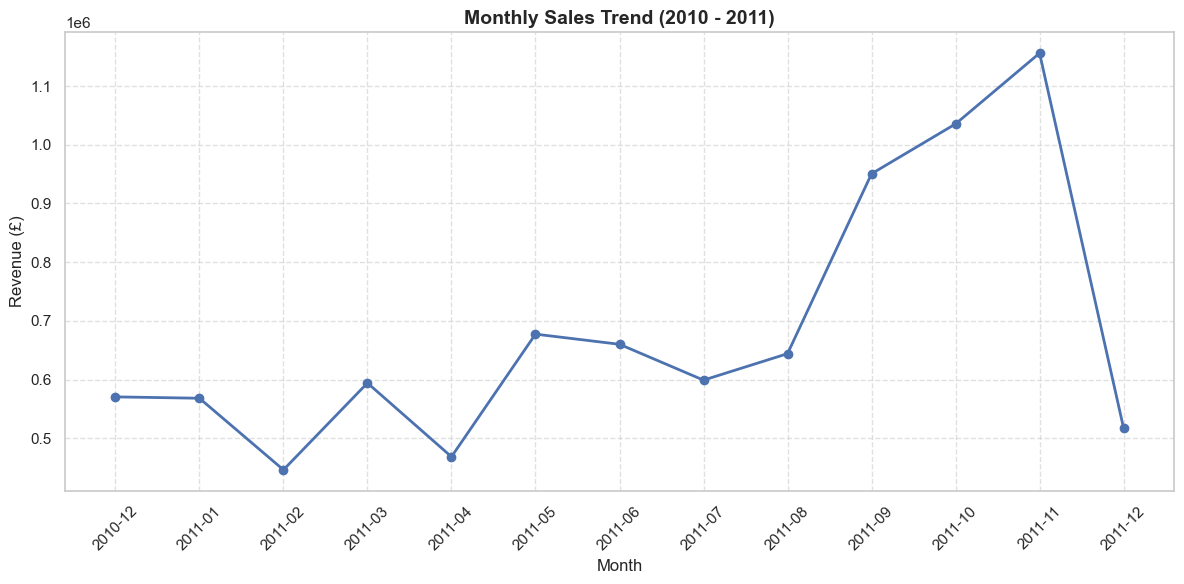

In [24]:
# =====================================================================
# STEP 3: VISUALIZATION - MONTHLY SALES TREND
# =====================================================================
plt.figure(figsize=(12, 6))

# Group by YearMonth (converted to string for plotting) and sum the Amount
monthly_sales = df_cleaned.groupby(df_cleaned['YearMonth'].astype(str))['Amount'].sum()

# Plot a clean line chart
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b', linewidth=2)

plt.title('Monthly Sales Trend (2010 - 2011)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

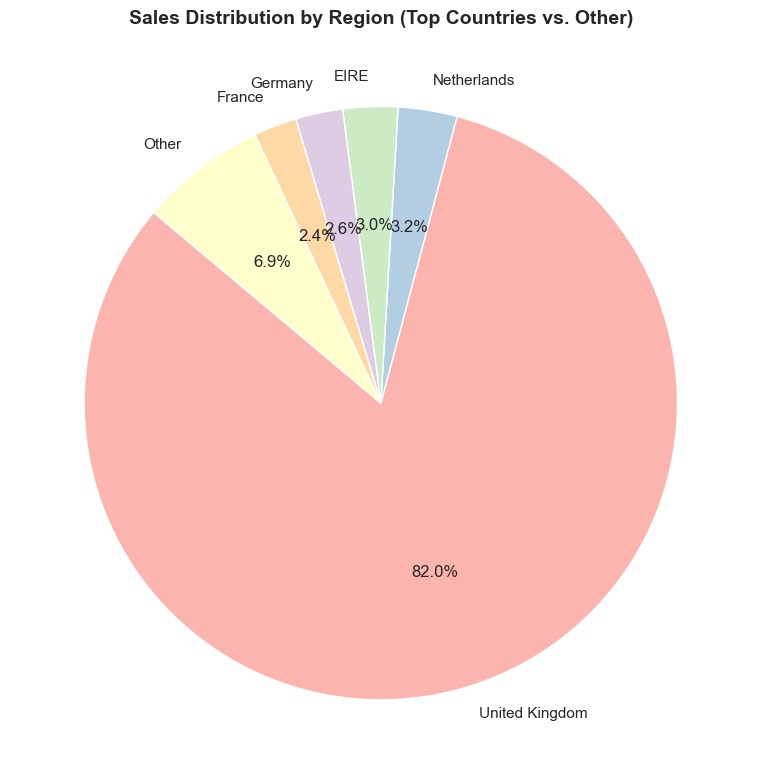

In [25]:
# =====================================================================
# STEP 4: VISUALIZATION - REGIONAL SALES DISTRIBUTION (PIE CHART)
# =====================================================================
plt.figure(figsize=(8, 8))

# Group by Country and sum the revenue
country_sales = df_cleaned.groupby('Country')['Amount'].sum()

# Since the UK dominates this dataset, we isolate the Top 5 countries 
# and group everything else into an 'Other' category so the pie chart is readable
top_countries = country_sales.nlargest(5)
other_countries_total = country_sales.drop(top_countries.index).sum()

# Combine them into a single series for plotting
pie_data = pd.concat([top_countries, pd.Series({'Other': other_countries_total})])

# Plot a clean, professional pie chart
plt.pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette("Pastel1"))

plt.title('Sales Distribution by Region (Top Countries vs. Other)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


C:\Users\muham\AppData\Local\Temp\ipykernel_25408\2428738346.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['{:,.0f}'.format(x) for x in current_values])


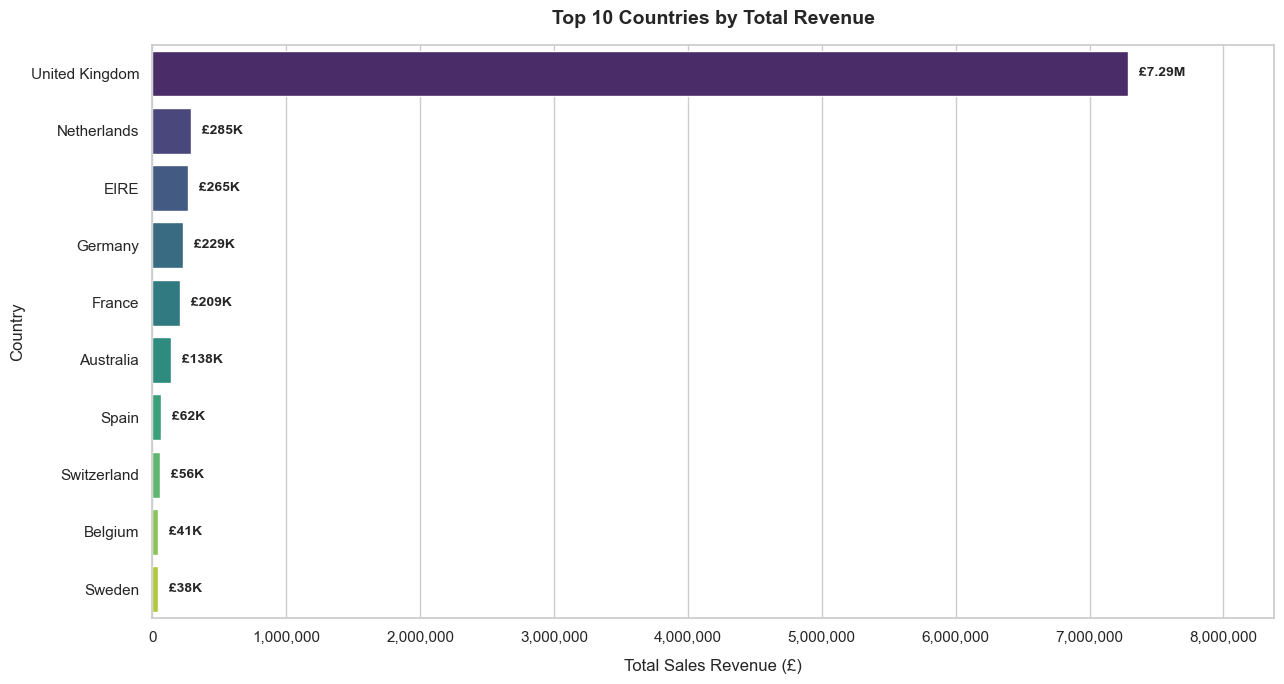

In [33]:
# =====================================================================
# VISUALIZATION: TOTAL SALES BY COUNTRY (CONTAINER LOOP FIX)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(13, 7))

# 1. Group by Country and sum up the 'Amount' column
country_sales = df_cleaned.groupby('Country')['Amount'].sum().nlargest(10)

# 2. Create the horizontal bar chart
sns.barplot(
    x=country_sales.values, 
    y=country_sales.index, 
    hue=country_sales.index, 
    palette="viridis", 
    legend=False,
    ax=ax
)

# 3. Create the text labels list (e.g., £6.81M or £230K)
labels = []
for v in country_sales.values:
    if v >= 1_000_000:
        labels.append(f' £{v/1_000_000:.2f}M')
    else:
        labels.append(f' £{v/1_000:.0f}K')

# FIX: Loop through each container layer and attach its matching label 
for i, container in enumerate(ax.containers):
    # Pass a list containing just the single text string for this specific bar
    ax.bar_label(container, labels=[labels[i]], padding=5, fontsize=10, fontweight='bold')

# 4. Add clear titles and labels
plt.title('Top 10 Countries by Total Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Sales Revenue (£)', fontsize=12, labelpad=10)
plt.ylabel('Country', fontsize=12)

# 5. Format x-axis numbers with commas so millions are easy to read
current_values = ax.get_xticks()
ax.set_xticklabels(['{:,.0f}'.format(x) for x in current_values])

# 6. Give the right side of the chart some extra space so the text labels don't get cut off
ax.set_xlim(0, country_sales.max() * 1.15)

# 7. Optimize layout and display the plot
plt.tight_layout()
plt.show()

In [34]:

# =====================================================================
# STEP 5: CATEGORY COMPARISON (UNITS VS REVENUE)
# =====================================================================
# Note: This specific dataset aggregates items by StockCode/Description instead of traditional category columns.
# We will aggregate by your top transaction drivers to print out a clean summary table.
print("--- Sales Summary by Key High-Volume Descriptions ---")
by_category = df_cleaned.groupby('Description').agg({
    'Amount': 'sum',
    'Quantity': 'sum'
}).nlargest(10, 'Amount')  # Top 10 items driving the business

# Rename columns to match project checklist terminology
by_category.columns = ['Total Revenue (£)', 'Total Units Sold']
print(by_category)

--- Sales Summary by Key High-Volume Descriptions ---
                                    Total Revenue (£)  Total Units Sold
Description                                                            
PAPER CRAFT , LITTLE BIRDIE                 168469.60             80995
REGENCY CAKESTAND 3 TIER                    142264.75             12384
WHITE HANGING HEART T-LIGHT HOLDER          100392.10             36706
JUMBO BAG RED RETROSPOT                      85040.54             46078
MEDIUM CERAMIC TOP STORAGE JAR               81416.73             77916
POSTAGE                                      77821.96              3121
PARTY BUNTING                                68785.23             15283
ASSORTED COLOUR BIRD ORNAMENT                56413.03             35263
Manual                                       53419.93              6939
RABBIT NIGHT LIGHT                           51251.24             27153


In [35]:
# Extract dynamic boundaries for the report text
total_records = len(df_cleaned)
min_date = df_cleaned['InvoiceDate'].min()
max_date = df_cleaned['InvoiceDate'].max()
best_month_period = df_cleaned.groupby('YearMonth')['Amount'].sum().idxmax()

print("="*60)
print("                     SALES ANALYSIS REPORT")
print("="*60)
print(f"Total Records Analyzed : {total_records:,}")
print(f"Date Range             : {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Total Revenue Generated: £ {total_revenue:,.2f}")
print(f"Average Sale Value     : £ {average_sale:,.2f}")
print(f"Median Sale Value      : £ {median_sale:,.2f}")
print(f"Best Performing Month  : {best_month_period}")
print("-"*60)
print("\nTop 5 Products by Revenue:")
print(top_products.head(5).to_string())
print("="*60)

                     SALES ANALYSIS REPORT
Total Records Analyzed : 392,733
Date Range             : 2010-12-01 to 2011-12-09
Total Revenue Generated: £ 8,887,226.89
Average Sale Value     : £ 22.63
Median Sale Value      : £ 12.39
Best Performing Month  : 2011-11
------------------------------------------------------------

Top 5 Products by Revenue:
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
